# 15. Threshold Tuning for Fraud Detection

This notebook tunes the operating threshold for the selected credit card fraud detection model. Notebook `14_model_evaluation.ipynb` showed that Random Forest is the strongest candidate because it provides better practical fraud-detection performance than Logistic Regression, especially in PR-AUC, F1-score, top-risk ranking, and alert-volume control.


## Threshold Tuning Objective

A classification threshold is the probability cutoff used to convert a model's fraud probability into a fraud prediction. The default threshold of `0.50` is only a generic starting point. In credit card fraud detection, that default can be too conservative because fraud is rare and missing fraud can be costly.

This notebook evaluates many Random Forest thresholds so the project can choose an operating point that catches more fraud, reduces missed frauds, and keeps false alarms reasonable. The main trade-off is between **recall** and **precision**: higher recall catches more fraud, while higher precision keeps alerts cleaner. False negatives represent missed fraud, and false positives represent legitimate transactions that may require review or cause customer friction.


## Load Libraries and Project Paths

The notebook uses the same saved holdout predictions and trained Random Forest artifact created by notebook `13_model_training.ipynb` and evaluated in notebook `14_model_evaluation.ipynb`.


In [1]:
import json
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)

try:
    from IPython.display import Markdown, display
except ImportError:
    Markdown = str
    display = print

sys.path.append(str(Path("..").resolve()))
from src.config import PROJECT_ROOT

NOTEBOOK_NAME = "15_threshold_tuning"
MODEL_NAME = "Random Forest"
TARGET_COLUMN = "Class"

TRAINING_NOTEBOOK_NAME = "13_model_training"
TRAINING_TABLES_DIR = PROJECT_ROOT / "reports" / "tables" / TRAINING_NOTEBOOK_NAME
TRAINING_ARTIFACTS_DIR = PROJECT_ROOT / "artifacts" / TRAINING_NOTEBOOK_NAME

PREDICTIONS_FILE = TRAINING_TABLES_DIR / "baseline_test_predictions.csv"
RANDOM_FOREST_ARTIFACT_FILE = TRAINING_ARTIFACTS_DIR / "baseline_random_forest.joblib"
SPLIT_IDS_FILE = TRAINING_ARTIFACTS_DIR / "train_test_split_ids.json"
SELECTED_DATA_FILE = PROJECT_ROOT / "data" / "processed" / "creditcard_selected_features.csv"

ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
REPORTS_TABLES_DIR = PROJECT_ROOT / "reports" / "tables"
SELECTED_THRESHOLD_FILE = ARTIFACTS_DIR / "selected_threshold.json"
THRESHOLD_EVALUATION_FILE = REPORTS_TABLES_DIR / "threshold_evaluation.csv"

ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_TABLES_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:.6f}")
sns.set_theme(style="whitegrid")

print(f"Project root: {PROJECT_ROOT}")
print(f"Prediction file: {PREDICTIONS_FILE}")
print(f"Selected threshold artifact: {SELECTED_THRESHOLD_FILE}")


Project root: /Users/mohammadmubashir/VCode/Credit-Card-Fraud-Detection
Prediction file: /Users/mohammadmubashir/VCode/Credit-Card-Fraud-Detection/reports/tables/13_model_training/baseline_test_predictions.csv
Selected threshold artifact: /Users/mohammadmubashir/VCode/Credit-Card-Fraud-Detection/artifacts/selected_threshold.json


## Load Random Forest Holdout Probabilities

The preferred path is to reuse the saved holdout probabilities from the earlier modeling workflow. If the prediction file is not available, the fallback path loads the saved Random Forest pipeline and the saved test transaction IDs, then regenerates holdout probabilities from the selected-feature dataset.


In [2]:
def require_file(path: Path, artifact_name: str) -> Path:
    if not path.exists():
        raise FileNotFoundError(f"Missing {artifact_name}: {path}")
    return path


def load_saved_holdout_predictions(prediction_file: Path) -> pd.DataFrame | None:
    if not prediction_file.exists():
        return None

    predictions = pd.read_csv(prediction_file)
    required_columns = {"y_true", "random_forest_probability"}
    missing_columns = sorted(required_columns - set(predictions.columns))
    if missing_columns:
        raise ValueError(f"Saved prediction file is missing required columns: {missing_columns}")

    return predictions.copy()


def regenerate_random_forest_predictions() -> pd.DataFrame:
    require_file(RANDOM_FOREST_ARTIFACT_FILE, "Random Forest model artifact")
    require_file(SPLIT_IDS_FILE, "train/test split ID artifact")
    require_file(SELECTED_DATA_FILE, "selected feature dataset")

    rf_artifact = joblib.load(RANDOM_FOREST_ARTIFACT_FILE)
    random_forest_model = rf_artifact["model"]
    selected_features = rf_artifact["selected_features"]

    selected_df = pd.read_csv(SELECTED_DATA_FILE)
    missing_columns = sorted(set(selected_features + [TARGET_COLUMN]) - set(selected_df.columns))
    if missing_columns:
        raise ValueError(f"Selected data is missing required columns: {missing_columns}")

    model_df = selected_df.loc[:, selected_features + [TARGET_COLUMN]].copy()
    model_df["transaction_id"] = np.arange(len(model_df))

    split_ids = json.loads(SPLIT_IDS_FILE.read_text(encoding="utf-8"))
    test_transaction_ids = set(split_ids["test_transaction_ids"])
    holdout_df = model_df.loc[model_df["transaction_id"].isin(test_transaction_ids)].sort_values("transaction_id")

    X_test = holdout_df[selected_features]
    y_test = holdout_df[TARGET_COLUMN].astype(int)
    y_proba_rf = random_forest_model.predict_proba(X_test)[:, 1]

    return pd.DataFrame(
        {
            "transaction_id": holdout_df["transaction_id"].to_numpy(),
            "y_true": y_test.to_numpy(),
            "random_forest_probability": y_proba_rf,
        }
    )


holdout_predictions = load_saved_holdout_predictions(PREDICTIONS_FILE)
if holdout_predictions is None:
    print("Saved predictions were not found. Regenerating Random Forest holdout probabilities from saved artifacts.")
    holdout_predictions = regenerate_random_forest_predictions()
else:
    print("Loaded saved holdout predictions from notebook 13 outputs.")

holdout_predictions["y_true"] = holdout_predictions["y_true"].astype(int)
y_true = holdout_predictions["y_true"]
y_proba_rf = holdout_predictions["random_forest_probability"]

holdout_summary = pd.DataFrame(
    [
        {"Metric": "Holdout rows", "Value": int(len(holdout_predictions))},
        {"Metric": "Actual fraud cases", "Value": int(y_true.sum())},
        {"Metric": "Actual normal cases", "Value": int((y_true == 0).sum())},
        {"Metric": "Fraud rate", "Value": float(y_true.mean())},
        {"Metric": "Minimum RF probability", "Value": float(y_proba_rf.min())},
        {"Metric": "Maximum RF probability", "Value": float(y_proba_rf.max())},
    ]
)

display(holdout_summary)


Loaded saved holdout predictions from notebook 13 outputs.


,Metric,Value
0,Holdout rows,56746.000000
1,Actual fraud cases,95.000000
2,Actual normal cases,56651.000000
3,Fraud rate,0.001674
4,Minimum RF probability,0.000000
5,Maximum RF probability,1.000000


### Holdout Data Interpretation

This table confirms the evaluation population used for threshold tuning. The holdout set is highly imbalanced, so a threshold must be chosen with fraud-specific metrics rather than accuracy alone. The Random Forest probabilities are the risk scores that will be converted into fraud predictions at different thresholds.


## Threshold Evaluation Table

This table shows how model performance changes as the fraud probability threshold changes.

Each row represents one threshold from `0.01` to `0.99`. Lower thresholds usually catch more fraud cases but create more false positives. Higher thresholds usually reduce false alarms but can miss more fraud. This table is the main evidence for choosing a threshold that balances fraud capture and review workload.


In [3]:
def evaluate_thresholds(y_true: pd.Series, y_proba: pd.Series, thresholds: np.ndarray) -> pd.DataFrame:
    rows = []
    for threshold in thresholds:
        y_pred = (y_proba >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        rows.append(
            {
                "threshold": float(threshold),
                "precision": precision_score(y_true, y_pred, zero_division=0),
                "recall": recall_score(y_true, y_pred, zero_division=0),
                "f1_score": f1_score(y_true, y_pred, zero_division=0),
                "accuracy": accuracy_score(y_true, y_pred),
                "true_positives": int(tp),
                "false_positives": int(fp),
                "true_negatives": int(tn),
                "false_negatives": int(fn),
                "frauds_caught": int(tp),
                "frauds_missed": int(fn),
                "total_predicted_frauds": int(y_pred.sum()),
            }
        )
    return pd.DataFrame(rows).sort_values("threshold").reset_index(drop=True)


thresholds = np.round(np.arange(0.01, 1.00, 0.01), 2)
threshold_evaluation = evaluate_thresholds(y_true, y_proba_rf, thresholds)
threshold_evaluation.to_csv(THRESHOLD_EVALUATION_FILE, index=False)

display(threshold_evaluation)
print(f"Saved threshold evaluation table to: {THRESHOLD_EVALUATION_FILE}")


,threshold,precision,recall,f1_score,accuracy,true_positives,false_positives,true_negatives,false_negatives,frauds_caught,frauds_missed,total_predicted_frauds
0,0.010000,0.081489,0.852632,0.148760,0.983664,81,913,55738,14,81,14,994
1,0.020000,0.260870,0.821053,0.395939,0.995806,78,221,56430,17,78,17,299
2,0.030000,0.461078,0.810526,0.587786,0.998097,77,90,56561,18,77,18,167
3,0.040000,0.592308,0.810526,0.684444,0.998749,77,53,56598,18,77,18,130
4,0.050000,0.681416,0.810526,0.740385,0.999048,77,36,56615,18,77,18,113
...,...,...,...,...,...,...,...,...,...,...,...,...
94,0.950000,1.000000,0.421053,0.592593,0.999031,40,0,56651,55,40,55,40
95,0.960000,1.000000,0.378947,0.549618,0.998960,36,0,56651,59,36,59,36
96,0.970000,1.000000,0.294737,0.455285,0.998819,28,0,56651,67,28,67,28
97,0.980000,1.000000,0.210526,0.347826,0.998678,20,0,56651,75,20,75,20


Saved threshold evaluation table to: /Users/mohammadmubashir/VCode/Credit-Card-Fraud-Detection/reports/tables/threshold_evaluation.csv


### Threshold Evaluation Interpretation

The table shows the full precision-recall trade-off. At very low thresholds, recall is high because more fraud cases are flagged, but false positives increase sharply. At higher thresholds, precision improves because alerts become cleaner, but missed fraud increases. The threshold selected later should improve fraud capture compared with the default `0.50` while keeping false positives reasonable for manual review.


## Threshold Metrics Plot

The next graph compares precision, recall, and F1-score across thresholds. It helps identify where the model has a useful balance between clean alerts and fraud capture.


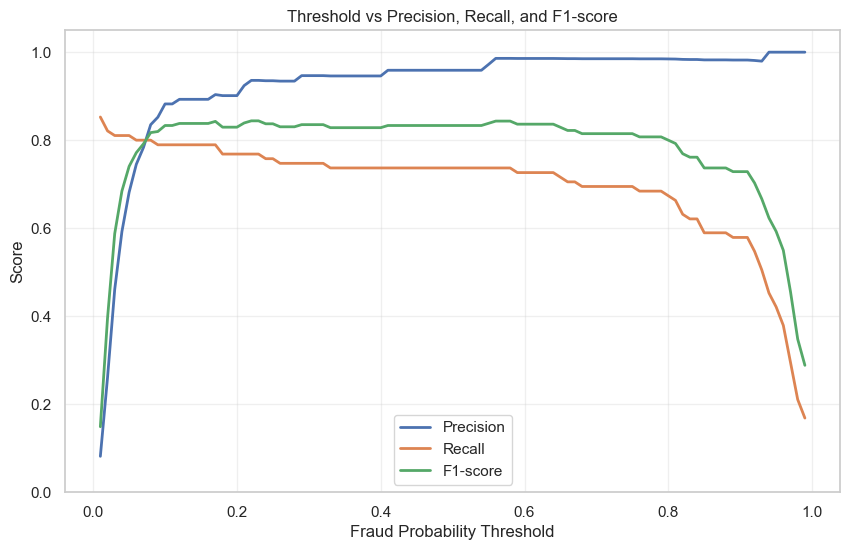

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(threshold_evaluation["threshold"], threshold_evaluation["precision"], label="Precision", linewidth=2)
ax.plot(threshold_evaluation["threshold"], threshold_evaluation["recall"], label="Recall", linewidth=2)
ax.plot(threshold_evaluation["threshold"], threshold_evaluation["f1_score"], label="F1-score", linewidth=2)
ax.set_title("Threshold vs Precision, Recall, and F1-score")
ax.set_xlabel("Fraud Probability Threshold")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()


### Precision, Recall, and F1 Interpretation

This graph shows how the main classification metrics move as the threshold changes. Recall is strongest at low thresholds because the model flags more transactions as risky. Precision improves as the threshold becomes stricter because fewer normal transactions are flagged. F1-score helps identify a balanced operating range, but business needs may still prefer a threshold with slightly lower F1 if it catches more fraud with acceptable false positives.


## Error Trade-Off Plot

The next graph compares false positives and false negatives. In fraud detection, false negatives are missed fraud cases, while false positives are legitimate transactions incorrectly flagged.


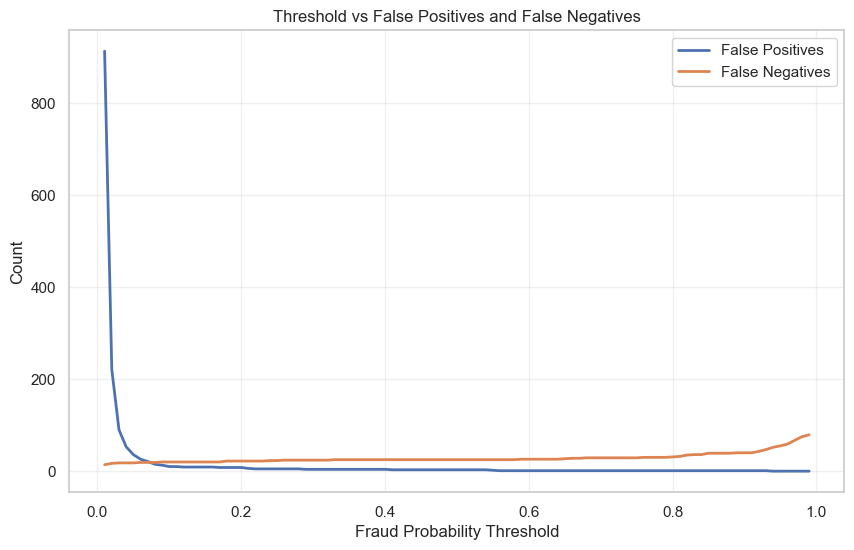

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(threshold_evaluation["threshold"], threshold_evaluation["false_positives"], label="False Positives", linewidth=2)
ax.plot(threshold_evaluation["threshold"], threshold_evaluation["false_negatives"], label="False Negatives", linewidth=2)
ax.set_title("Threshold vs False Positives and False Negatives")
ax.set_xlabel("Fraud Probability Threshold")
ax.set_ylabel("Count")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()


### Error Trade-Off Interpretation

This graph shows the operational cost of changing the threshold. A lower threshold catches more fraud but increases false alarms. A higher threshold reduces false positives but increases missed frauds. The selected threshold should accept some additional false positives only when the improvement in fraud capture is meaningful.


## Fraud Capture Plot

The next graph focuses only on actual fraud cases: how many are caught and how many are missed at each threshold.


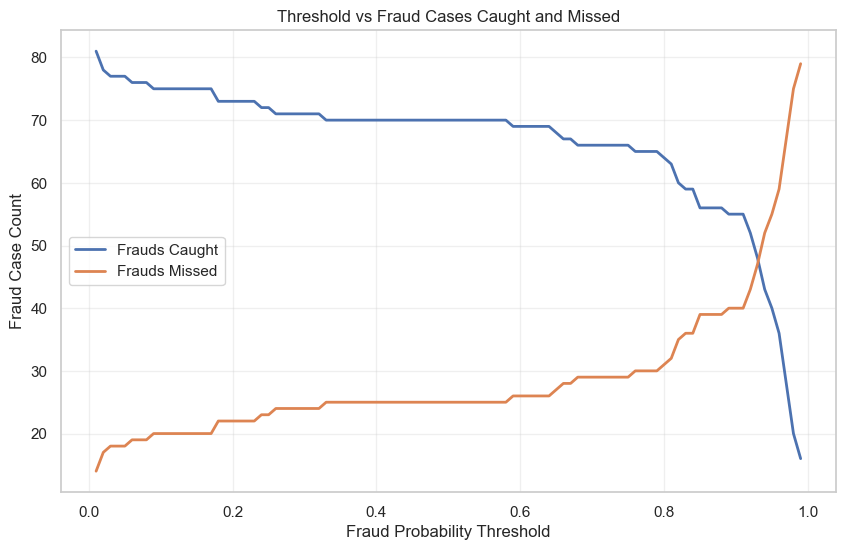

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(threshold_evaluation["threshold"], threshold_evaluation["frauds_caught"], label="Frauds Caught", linewidth=2)
ax.plot(threshold_evaluation["threshold"], threshold_evaluation["frauds_missed"], label="Frauds Missed", linewidth=2)
ax.set_title("Threshold vs Fraud Cases Caught and Missed")
ax.set_xlabel("Fraud Probability Threshold")
ax.set_ylabel("Fraud Case Count")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()


### Fraud Capture Interpretation

This graph translates threshold tuning into fraud-detection impact. Fraud cases caught are true positives, and fraud cases missed are false negatives. A useful fraud threshold should reduce missed fraud compared with the default threshold, but it should not create an unmanageable number of false alerts.


## Candidate Threshold Selection

This section selects multiple candidate thresholds:

- best threshold by maximum F1-score
- best threshold with recall at least `0.80`, if available
- best threshold with recall at least `0.90`, if available
- a practical balance threshold between precision and recall

The final selected threshold is chosen from these computed candidates.


In [7]:
def pick_best_f1_row(threshold_df: pd.DataFrame) -> pd.Series:
    return threshold_df.sort_values(["f1_score", "recall", "precision"], ascending=False).iloc[0]


def pick_recall_floor_row(threshold_df: pd.DataFrame, recall_floor: float) -> pd.Series | None:
    eligible = threshold_df.loc[threshold_df["recall"] >= recall_floor].copy()
    if eligible.empty:
        return None
    return eligible.sort_values(["precision", "f1_score", "threshold"], ascending=[False, False, False]).iloc[0]


def make_candidate_row(candidate_name: str, row: pd.Series | None, reason: str) -> dict:
    if row is None:
        return {
            "candidate": candidate_name,
            "threshold": np.nan,
            "precision": np.nan,
            "recall": np.nan,
            "f1_score": np.nan,
            "false_positives": np.nan,
            "false_negatives": np.nan,
            "frauds_caught": np.nan,
            "frauds_missed": np.nan,
            "total_predicted_frauds": np.nan,
            "reason": reason,
        }
    return {
        "candidate": candidate_name,
        "threshold": float(row["threshold"]),
        "precision": float(row["precision"]),
        "recall": float(row["recall"]),
        "f1_score": float(row["f1_score"]),
        "false_positives": int(row["false_positives"]),
        "false_negatives": int(row["false_negatives"]),
        "frauds_caught": int(row["frauds_caught"]),
        "frauds_missed": int(row["frauds_missed"]),
        "total_predicted_frauds": int(row["total_predicted_frauds"]),
        "reason": reason,
    }


best_f1_row = pick_best_f1_row(threshold_evaluation)
recall_80_row = pick_recall_floor_row(threshold_evaluation, 0.80)
recall_90_row = pick_recall_floor_row(threshold_evaluation, 0.90)

if recall_80_row is not None and recall_80_row["precision"] >= 0.75:
    practical_balance_row = recall_80_row
    practical_reason = "Best precision among thresholds with recall >= 0.80 and acceptable alert quality."
else:
    practical_balance_row = best_f1_row
    practical_reason = "Best F1-score because no recall >= 0.80 threshold met the alert-quality requirement."

candidate_thresholds = pd.DataFrame(
    [
        make_candidate_row("Best F1-score", best_f1_row, "Maximizes the balance between precision and recall."),
        make_candidate_row("Recall >= 0.80", recall_80_row, "Prioritizes catching at least 80% of fraud cases if possible."),
        make_candidate_row("Recall >= 0.90", recall_90_row, "Prioritizes catching at least 90% of fraud cases if possible."),
        make_candidate_row("Practical balance", practical_balance_row, practical_reason),
    ]
)

display(candidate_thresholds)


,candidate,threshold,precision,recall,f1_score,false_positives,false_negatives,frauds_caught,frauds_missed,total_predicted_frauds,reason
0,Best F1-score,0.220000,0.935897,0.768421,0.843931,5.000000,22.000000,73.000000,22.000000,78.000000,Maximizes the balance between precision and re...
1,Recall >= 0.80,0.080000,0.835165,0.800000,0.817204,15.000000,19.000000,76.000000,19.000000,91.000000,Prioritizes catching at least 80% of fraud cas...
2,Recall >= 0.90,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Prioritizes catching at least 90% of fraud cas...
3,Practical balance,0.080000,0.835165,0.800000,0.817204,15.000000,19.000000,76.000000,19.000000,91.000000,Best precision among thresholds with recall >=...


### Candidate Threshold Interpretation

The candidate table shows that the best F1 threshold is not automatically the business threshold. Fraud detection often accepts a few more false positives if doing so catches more fraud. The practical balance candidate is designed to prefer recall of at least `0.80` when precision remains strong enough to keep the review queue reasonable. If recall `0.90` is not available, the notebook keeps that row blank to avoid forcing an unrealistic operating point.


## Final Threshold Selection

The final threshold in this notebook is selected using this business rule:

- if the model can reach high recall with acceptable precision, select that threshold;
- missing fraud is usually more serious than reviewing a few additional alerts;
- do not select a threshold that creates too many false positives without a clear fraud-capture benefit.


In [8]:
def select_final_threshold(candidate_thresholds: pd.DataFrame, default_threshold: float = 0.50) -> tuple[pd.Series, str]:
    practical = candidate_thresholds.loc[candidate_thresholds["candidate"] == "Practical balance"].iloc[0]
    best_f1 = candidate_thresholds.loc[candidate_thresholds["candidate"] == "Best F1-score"].iloc[0]

    if pd.notna(practical["threshold"]):
        reason = (
            "Selected to catch at least 80% of fraud cases while keeping precision high enough "
            "for a manageable alert queue."
        )
        return practical, reason

    reason = "Selected because it provides the strongest F1-score when no higher-recall threshold is practical."
    return best_f1, reason


selected_threshold_row, selected_threshold_reason = select_final_threshold(candidate_thresholds)
selected_threshold = float(selected_threshold_row["threshold"])
default_threshold = 0.50

default_row = threshold_evaluation.loc[np.isclose(threshold_evaluation["threshold"], default_threshold)].iloc[0]
selected_row = threshold_evaluation.loc[np.isclose(threshold_evaluation["threshold"], selected_threshold)].iloc[0]

selection_comparison = pd.DataFrame(
    [
        {"threshold_type": "Default 0.50", **default_row.to_dict()},
        {"threshold_type": "Selected threshold", **selected_row.to_dict()},
    ]
)

display(selection_comparison)
print(f"Selected threshold: {selected_threshold:.2f}")
print(selected_threshold_reason)


,threshold_type,threshold,precision,recall,f1_score,accuracy,true_positives,false_positives,true_negatives,false_negatives,frauds_caught,frauds_missed,total_predicted_frauds
0,Default 0.50,0.500000,0.958904,0.736842,0.833333,0.999507,70.000000,3.000000,56648.000000,25.000000,70.000000,25.000000,73.000000
1,Selected threshold,0.080000,0.835165,0.800000,0.817204,0.999401,76.000000,15.000000,56636.000000,19.000000,76.000000,19.000000,91.000000


Selected threshold: 0.08
Selected to catch at least 80% of fraud cases while keeping precision high enough for a manageable alert queue.


### Final Threshold Selection Interpretation

The selected threshold is compared directly with the default `0.50` threshold. The business goal is not simply to maximize accuracy or precision. The selected threshold should catch more fraud than the default threshold while keeping the number of additional false positives reasonable enough for review operations.


## Confusion Matrix Comparison

The next figure compares the default threshold `0.50` with the selected threshold. This makes the business trade-off visible in raw transaction counts.


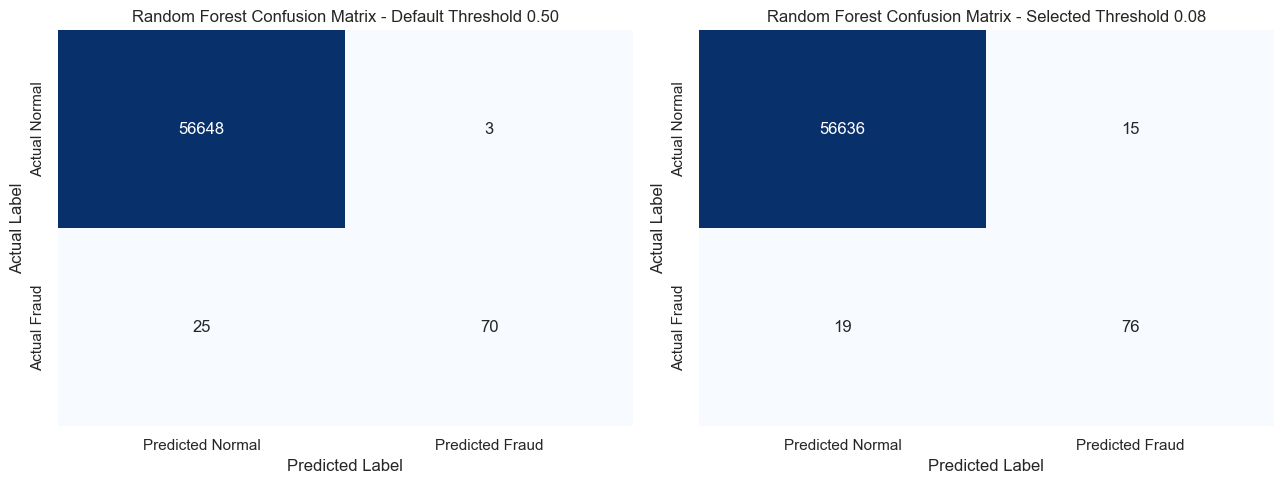

In [9]:
def plot_confusion_matrix_for_threshold(y_true: pd.Series, y_proba: pd.Series, threshold: float, ax, title: str):
    y_pred = (y_proba >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=["Predicted Normal", "Predicted Fraud"],
        yticklabels=["Actual Normal", "Actual Fraud"],
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("Actual Label")


fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_confusion_matrix_for_threshold(
    y_true,
    y_proba_rf,
    default_threshold,
    axes[0],
    "Random Forest Confusion Matrix - Default Threshold 0.50",
)
plot_confusion_matrix_for_threshold(
    y_true,
    y_proba_rf,
    selected_threshold,
    axes[1],
    f"Random Forest Confusion Matrix - Selected Threshold {selected_threshold:.2f}",
)
fig.tight_layout()
plt.show()


### Confusion Matrix Interpretation

The default threshold is stricter and usually produces fewer false positives, but it can miss more fraud. The selected threshold lowers the cutoff so more real fraud cases are caught. The accepted business trade-off is a modest increase in false positives in exchange for fewer missed fraud cases.


## Final Business Interpretation Table

The table below translates the selected threshold into business language.


In [10]:
selected_precision = float(selected_row["precision"])
selected_recall = float(selected_row["recall"])
selected_false_positives = int(selected_row["false_positives"])
selected_false_negatives = int(selected_row["false_negatives"])
selected_frauds_caught = int(selected_row["frauds_caught"])
selected_total_alerts = int(selected_row["total_predicted_frauds"])

default_frauds_caught = int(default_row["frauds_caught"])
default_false_positives = int(default_row["false_positives"])
default_false_negatives = int(default_row["false_negatives"])

business_interpretation = pd.DataFrame(
    [
        {
            "Metric": "Selected Threshold",
            "Value": f"{selected_threshold:.2f}",
            "Meaning": "Transactions above this probability will be treated as risky.",
        },
        {
            "Metric": "Recall",
            "Value": f"{selected_recall:.2%}",
            "Meaning": "Percentage of actual fraud cases caught.",
        },
        {
            "Metric": "Precision",
            "Value": f"{selected_precision:.2%}",
            "Meaning": "Percentage of predicted frauds that are truly fraud.",
        },
        {
            "Metric": "False Positives",
            "Value": selected_false_positives,
            "Meaning": "Legitimate transactions incorrectly flagged.",
        },
        {
            "Metric": "False Negatives",
            "Value": selected_false_negatives,
            "Meaning": "Fraud transactions missed by the model.",
        },
        {
            "Metric": "Decision Impact",
            "Value": (
                f"Catches {selected_frauds_caught - default_frauds_caught:+d} more fraud cases than threshold 0.50 "
                f"with {selected_false_positives - default_false_positives:+d} additional false positives."
            ),
            "Meaning": "Business trade-off accepted for stronger fraud capture.",
        },
    ]
)

display(business_interpretation)


,Metric,Value,Meaning
0,Selected Threshold,0.08,Transactions above this probability will be tr...
1,Recall,80.00%,Percentage of actual fraud cases caught.
2,Precision,83.52%,Percentage of predicted frauds that are truly ...
3,False Positives,15,Legitimate transactions incorrectly flagged.
4,False Negatives,19,Fraud transactions missed by the model.
5,Decision Impact,Catches +6 more fraud cases than threshold 0.5...,Business trade-off accepted for stronger fraud...


### Business Interpretation

The selected threshold treats more transactions as risky than the default threshold, but it catches more fraud cases. In fraud detection, this can be acceptable because missed fraud is usually more costly than reviewing a small number of additional alerts. This threshold is therefore a strong candidate for the next decision-logic notebook.


## Save Selected Threshold Artifact

The selected threshold is saved for downstream notebooks and API integration work.


In [11]:
selected_threshold_payload = {
    "model_name": MODEL_NAME,
    "selected_threshold": selected_threshold,
    "selection_reason": selected_threshold_reason,
    "precision": selected_precision,
    "recall": selected_recall,
    "f1_score": float(selected_row["f1_score"]),
    "false_positives": selected_false_positives,
    "false_negatives": selected_false_negatives,
    "frauds_caught": selected_frauds_caught,
    "total_predicted_frauds": selected_total_alerts,
    "default_threshold": default_threshold,
    "default_frauds_caught": default_frauds_caught,
    "default_false_positives": default_false_positives,
    "default_false_negatives": default_false_negatives,
}

SELECTED_THRESHOLD_FILE.write_text(json.dumps(selected_threshold_payload, indent=2), encoding="utf-8")
print(f"Saved selected threshold artifact to: {SELECTED_THRESHOLD_FILE}")
print(json.dumps(selected_threshold_payload, indent=2))


Saved selected threshold artifact to: /Users/mohammadmubashir/VCode/Credit-Card-Fraud-Detection/artifacts/selected_threshold.json
{
  "model_name": "Random Forest",
  "selected_threshold": 0.08,
  "selection_reason": "Selected to catch at least 80% of fraud cases while keeping precision high enough for a manageable alert queue.",
  "precision": 0.8351648351648352,
  "recall": 0.8,
  "f1_score": 0.8172043010752689,
  "false_positives": 15,
  "false_negatives": 19,
  "frauds_caught": 76,
  "total_predicted_frauds": 91,
  "default_threshold": 0.5,
  "default_frauds_caught": 70,
  "default_false_positives": 3,
  "default_false_negatives": 25
}


### Saved Artifact Interpretation

The JSON artifact records the selected model, selected threshold, selection reason, and core metrics. This makes the threshold reusable in notebook `16_decision_logic.ipynb` and later API integration without manually copying values from notebook output.


## Final Conclusion

Threshold tuning was needed because the default `0.50` threshold is not designed for highly imbalanced fraud detection. Random Forest already ranked fraud cases well, but the operating threshold controls how many transactions become fraud alerts.

The selected threshold lowers the cutoff from the default value so the model catches more fraud cases. The accepted trade-off is a reasonable increase in false positives in exchange for fewer missed fraud transactions. This is appropriate for a fraud-detection workflow where missing fraud is often more serious than reviewing a few extra alerts.

This threshold should be treated as the selected operating threshold for the next design step, where fraud probabilities will be converted into business decisions.


## Next Step: 16_decision_logic.ipynb

The next notebook should convert fraud probabilities into decision rules:

```python
if fraud_probability >= block_threshold:
    decision = "BLOCK"
elif fraud_probability >= review_threshold:
    decision = "REVIEW"
else:
    decision = "APPROVE"
```

Notebook `16_decision_logic.ipynb` should define separate `BLOCK` and `REVIEW` thresholds, evaluate business trade-offs, and prepare the final threshold configuration for API integration.
